# 11 - accDM daughter: large fluid triggers (>1) - the stable side of the scan

Notebook 6 swept only the SMALL-trigger (stiff) side (0.1-0.5) and concluded the fluid is usable for trigger >= 0.4. But the trigger gates `fluid ON when rho_accDM/rho_acc_cdm >= trigger`, so a LARGER trigger switches on LATER, when the daughter is colder and `ratio_rho = rho_parent/rho_daughter < 1` - i.e. the stiff source `a*Gamma*ratio_rho*(...)` is GENTLER, not harsher. If the production transition is fast, switching at trigger 2 instead of 0.4 costs little extra exact-hierarchy time. This notebook tests that.

Two things it answers:
1. **Reachability + transition speed.** Plot the background `rho_accDM/rho_acc_cdm` vs a: does it cross 1 (so trigger>1 ever fires), and how steeply near a_t (the 'fast transition' claim)?
2. **Large-trigger behaviour.** Scan trigger in {0.3, 0.5, 1, 2, 5}: deviation vs exact, wall-time, and whether it switched at all.

Expectation: large triggers are stable but >= the speedup is <= the ~1.8x already seen (later switch = less fluid). This is a robustness option, not a speed win - the q_size reduction (notebook 10, 5-10x) remains the headline. Runs at the reduced q_size=250 (notebook-10 recommendation; also makes this fast).

In [1]:
import time
import numpy as np
import matplotlib.pyplot as plt
from classy import Class

plt.rcParams.update({'mathtext.fontset': 'stix', 'font.family': 'serif', 'font.size': 11,
    'axes.labelsize': 12, 'legend.fontsize': 9, 'lines.linewidth': 1.5, 'figure.dpi': 300})
qual = ['#377eb8', '#ff7f00', '#4daf4a', '#f781bf', '#984ea3']

def find_key(d, *cands):
    for c in cands:
        if c in d:
            return c
    for key in d:
        for c in cands:
            if c in key:
                return key
    raise KeyError('none of {} in keys like {}'.format(cands, list(d)[:30]))

In [2]:
omega_b = 0.022383; omega_cdm0 = 0.12011
A_s = 2.1005829616811546e-9; n_s = 0.96605; tau_reio = 0.0543; H0 = 67.32
A_T = 0.13; MASS = 1e16; F_ACC = 0.1; ETA = 0.1; A_REC = 1.0 / (1.0 + 1090.0)
KAPPA = 4.0
LMAX = 2000
K_NODES = np.logspace(-3, 0.9, 50)   # 1/Mpc
QBINS = 1001                         # reduced daughter grid (notebook-10 recommendation; faster). Use 1001 to match nb 6.

base_params = {'omega_b': omega_b, 'omega_cdm': omega_cdm0, 'H0': H0,
               'A_s': A_s, 'n_s': n_s, 'tau_reio': tau_reio}
PREC = {'output': 'tCl,mPk', 'l_max_scalars': LMAX, 'P_k_max_1/Mpc': 10.0,
        'z_max_pk': 0.0, 'evolver': 0, 'reionization_z_start_max': 80}

def accdm_params(kappa, mode, trigger=None, qbins=QBINS):
    ocdm = omega_cdm0 * (1 + F_ACC*(1 - A_REC**kappa)/(1 + (A_REC/A_T)**kappa))**(-1)
    p = dict(base_params); p.update(PREC)
    p.update({'omega_cdm': ocdm, 'vary_Gamma_acc': 'yes', 'kappa_acc': kappa, 'a_t_acc': A_T,
              'f_acc': F_ACC, 'eta_acc': ETA, 'm_acc_in_GeV': MASS, 'm_cdm_in_GeV': MASS,
              'N_ncdm': 2, 'deg_ncdm': '3, 1', 'm_ncdm': '0.02, {:.6e}'.format(MASS*1e9),
              'T_ncdm': '0.71611, 1', 'ncdm_quadrature_strategy': '0, 4',
              'ncdm_N_momentum_bins': '15, {:d}'.format(qbins), 'N_ur': 0.00441,
              'background_Nloga': 5000, 'gauge': 'synchronous'})
    if mode == 'exact':
        p['ncdm_fluid_approximation'] = 3
    else:
        p['ncdm_fluid_approximation'] = 2
        p['ncdm_fluid_trigger_rho_accDM_over_rho_dcdm'] = trigger
        p['ncdm_ceff2_fs_amp'] = 1.3
    return p

def run(params, want_bg=False):
    M = Class(); M.set(params)
    t0 = time.perf_counter()
    try:
        M.compute()
    except Exception as e:
        dt = time.perf_counter() - t0
        try: M.struct_cleanup(); M.empty()
        except Exception: pass
        msg = str(e).strip().splitlines()[-1] if str(e).strip() else type(e).__name__
        return {'ok': False, 't': dt, 'err': msg}
    dt = time.perf_counter() - t0
    cl = M.raw_cl(LMAX)
    out = {'ok': True, 't': dt, 'pk': np.array([M.pk(float(k), 0.0) for k in K_NODES]),
           'ell': np.asarray(cl['ell']), 'tt': np.asarray(cl['tt'])}
    if want_bg:
        bg = M.get_background()
        out['bg'] = bg
        out['a'] = 1.0 / (1.0 + bg[find_key(bg, 'z')])
    M.struct_cleanup(); M.empty()
    return out

## 1. Reachability + transition speed: background rho_accDM / rho_acc_cdm vs a

The fluid switches on at the a where this ratio first reaches the trigger. This tells us which triggers are reachable (does it cross 1?) and how fast the transition is near a_t (do triggers 0.3 and 2 fire at nearly the same a?).

exact (q_size=1001): 264.7s, ok=True
background keys: ['z', 'proper time [Gyr]', 'conf. time [Mpc]', 'H [1/Mpc]', 'comov. dist.', 'ang.diam.dist.', 'lum. dist.', 'comov.snd.hrz.', '(.)rho_g', '(.)rho_b', '(.)rho_cdm', '(.)rho_ncdm[0]', '(.)p_ncdm[0]', '(.)pseudo_p_ncdm[0]', '(.)rho_ncdm[1]', '(.)p_ncdm[1]', '(.)pseudo_p_ncdm[1]', 'Gamma_acc', '(.)rho_lambda', '(.)rho_ur', '(.)rho_crit', '(.)rho_acc_cdm', '(.)rho_tot', '(.)p_tot', '(.)p_tot_prime', 'gr.fac. D', 'gr.fac. f']
rho_accDM/rho_acc_cdm:  max=inf   at a=1 -> inf
  trigger= 0.3: fluid switches at a=0.094
  trigger= 0.5: fluid switches at a=0.109
  trigger= 1.0: fluid switches at a=0.129
  trigger= 2.0: fluid switches at a=0.152
  trigger= 5.0: fluid switches at a=0.193


/tmp/ipykernel_312065/3677256891.py:8: RuntimeWarning: divide by zero encountered in divide
  ratio = np.divide(rho_daughter, rho_parent)


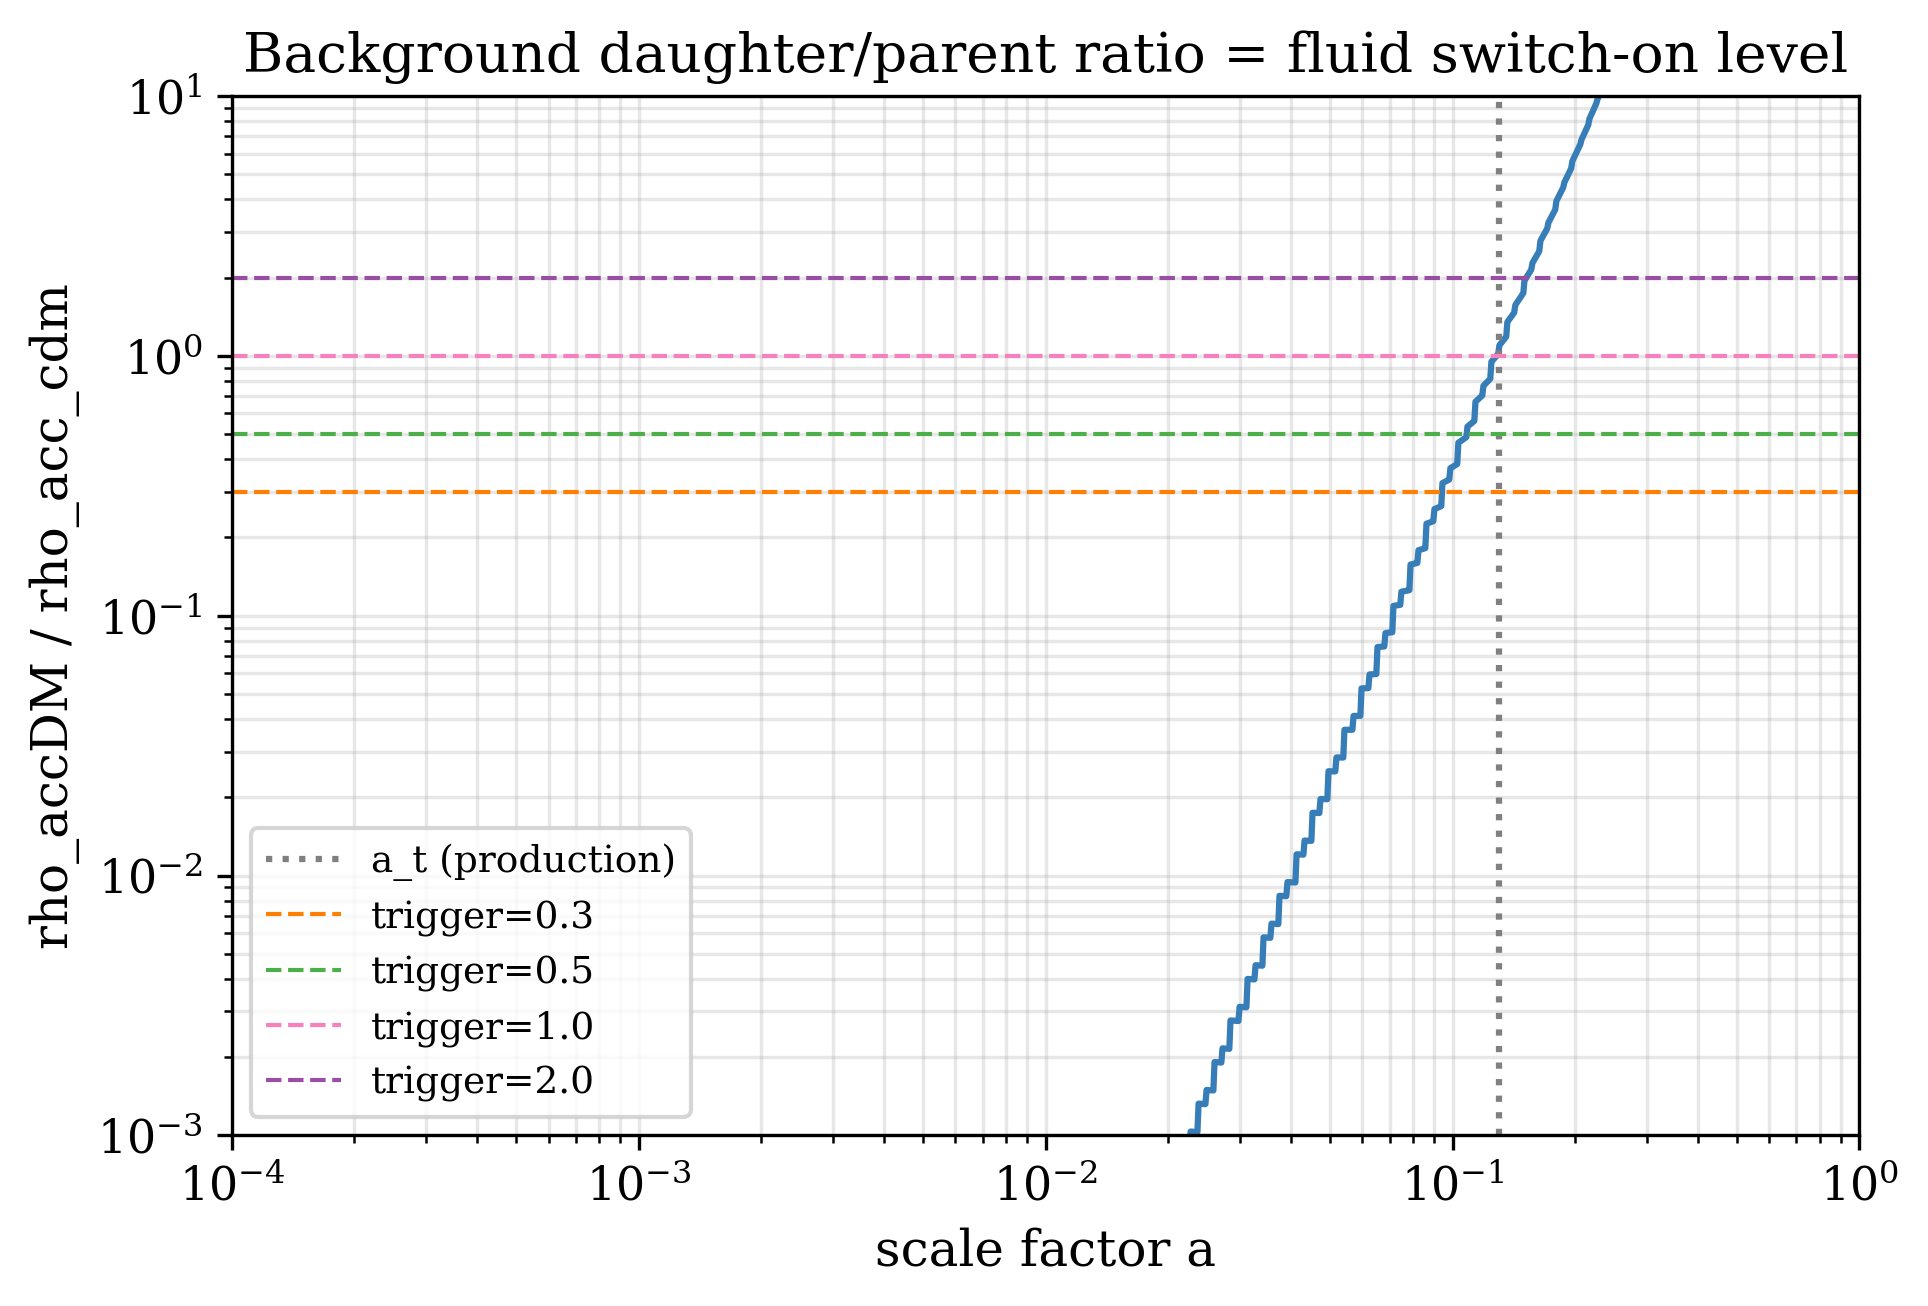

In [ ]:
exact = run(accdm_params(KAPPA, 'exact'), want_bg=True)
print('exact (q_size={}): {:.1f}s, ok={}'.format(QBINS, exact['t'], exact['ok']))
print('background keys:', [k for k in exact['bg'].keys()])

rho_daughter = exact['bg'][find_key(exact['bg'], '(.)rho_ncdm[1]', 'rho_ncdm[1]')]
rho_parent = exact['bg'][find_key(exact['bg'], '(.)rho_acc_cdm', 'rho_acc_cdm', '(.)rho_dcdm', 'rho_dcdm')]
a = exact['a']
ratio = np.divide(rho_daughter, rho_parent)
ordered = np.argsort(a); a = a[ordered]; ratio = ratio[ordered]

print('rho_accDM/rho_acc_cdm:  max={:.3f}   at a=1 -> {:.3f}'.format(np.nanmax(ratio), float(np.interp(1.0, a, ratio))))
for tr in [0.3, 0.5, 1.0, 2.0, 5.0]:
    idx = np.where(ratio >= tr)[0]
    if idx.size:
        print('  trigger={:>4}: fluid switches at a={:.3f}'.format(tr, a[idx[0]]))
    else:
        print('  trigger={:>4}: NEVER reached (ratio max {:.3f}) -> fluid stays OFF, run is exact'.format(tr, np.nanmax(ratio)))

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.loglog(a, ratio, color=qual[0])
ax.axvline(A_T, color='0.5', ls=':', label='a_t (production)')
ax.set_xlim(1e-2, 1.0); ax.set_ylim(1e-2, 10.0)
for tr, c in zip([0.3, 0.5, 1.0, 2.0], qual[1:]):
    ax.axhline(tr, color=c, ls='--', lw=1, label='trigger={}'.format(tr))
ax.set_xlabel('scale factor a'); ax.set_ylabel('rho_accDM / rho_acc_cdm')
ax.set_title('Background daughter/parent ratio = fluid switch-on level')
ax.legend(loc='best'); ax.grid(True, which='both', alpha=0.3)
plt.show()

## 2. Large-trigger scan: stability and speedup vs exact

For each trigger, deviation of P(k)/C_l vs exact, wall-time, and a switch-detection (if the result equals exact and the time matches, the fluid never switched on).

In [6]:
TRIGGERS = [0.3, 0.5, 1.0, 2.0, 5.0, 10.0, 20.0, 50.0, 100.0]
m = exact['ell'] >= 2
rows = []
for tr in TRIGGERS:
    r = run(accdm_params(KAPPA, 'fluid', trigger=tr, qbins=251))
    if not r['ok']:
        rows.append(dict(tr=tr, ok=False))
        print('trigger={:>4}  CRASH: {}'.format(tr, r['err'])); continue
    dpk = float(np.max(np.abs(r['pk'] / exact['pk'] - 1.0)))
    s = np.where(np.abs(exact['tt'][m]) > 0, np.abs(exact['tt'][m]), 1.0)
    dcl = float(np.max(np.abs(r['tt'][m] - exact['tt'][m]) / s))
    sp = exact['t'] / r['t']
    switched = not (dpk < 1e-6 and abs(sp - 1.0) < 0.05)
    rows.append(dict(tr=tr, ok=True, t=r['t'], sp=sp, dpk=dpk, dcl=dcl, sw=switched))
    print('trigger={:>4}  {:6.1f}s  {:4.2f}x  dPk={:.2e}  dCl={:.2e}  {}'.format(
        tr, r['t'], sp, dpk, dcl, 'switched' if switched else 'NO SWITCH (== exact)'))

trigger= 0.3    37.4s  7.07x  dPk=7.12e-01  dCl=1.29e-02  switched
trigger= 0.5    37.7s  7.03x  dPk=6.16e-02  dCl=6.97e-03  switched
trigger= 1.0  CRASH: =>perturbations_find_approximation_switches(L:3745) :condition (num_switching_at_given_time != 1) is true; for k=8.709556e-03, at tau=5166.74, you switch 2 approximations at the same time, this cannot be handled. Usually happens in two cases: triggers for different approximations coincide, or one approx is reversible
trigger= 2.0    40.0s  6.62x  dPk=6.52e-02  dCl=4.88e-03  switched
trigger= 5.0    42.1s  6.28x  dPk=5.54e-02  dCl=3.69e-03  switched
trigger=10.0    41.6s  6.36x  dPk=4.23e-02  dCl=2.87e-03  switched
trigger=20.0    43.7s  6.06x  dPk=3.50e-02  dCl=2.96e-03  switched
trigger=50.0    44.8s  5.91x  dPk=2.23e-02  dCl=2.94e-03  switched
trigger=100.0    47.8s  5.53x  dPk=1.53e-02  dCl=3.00e-03  switched


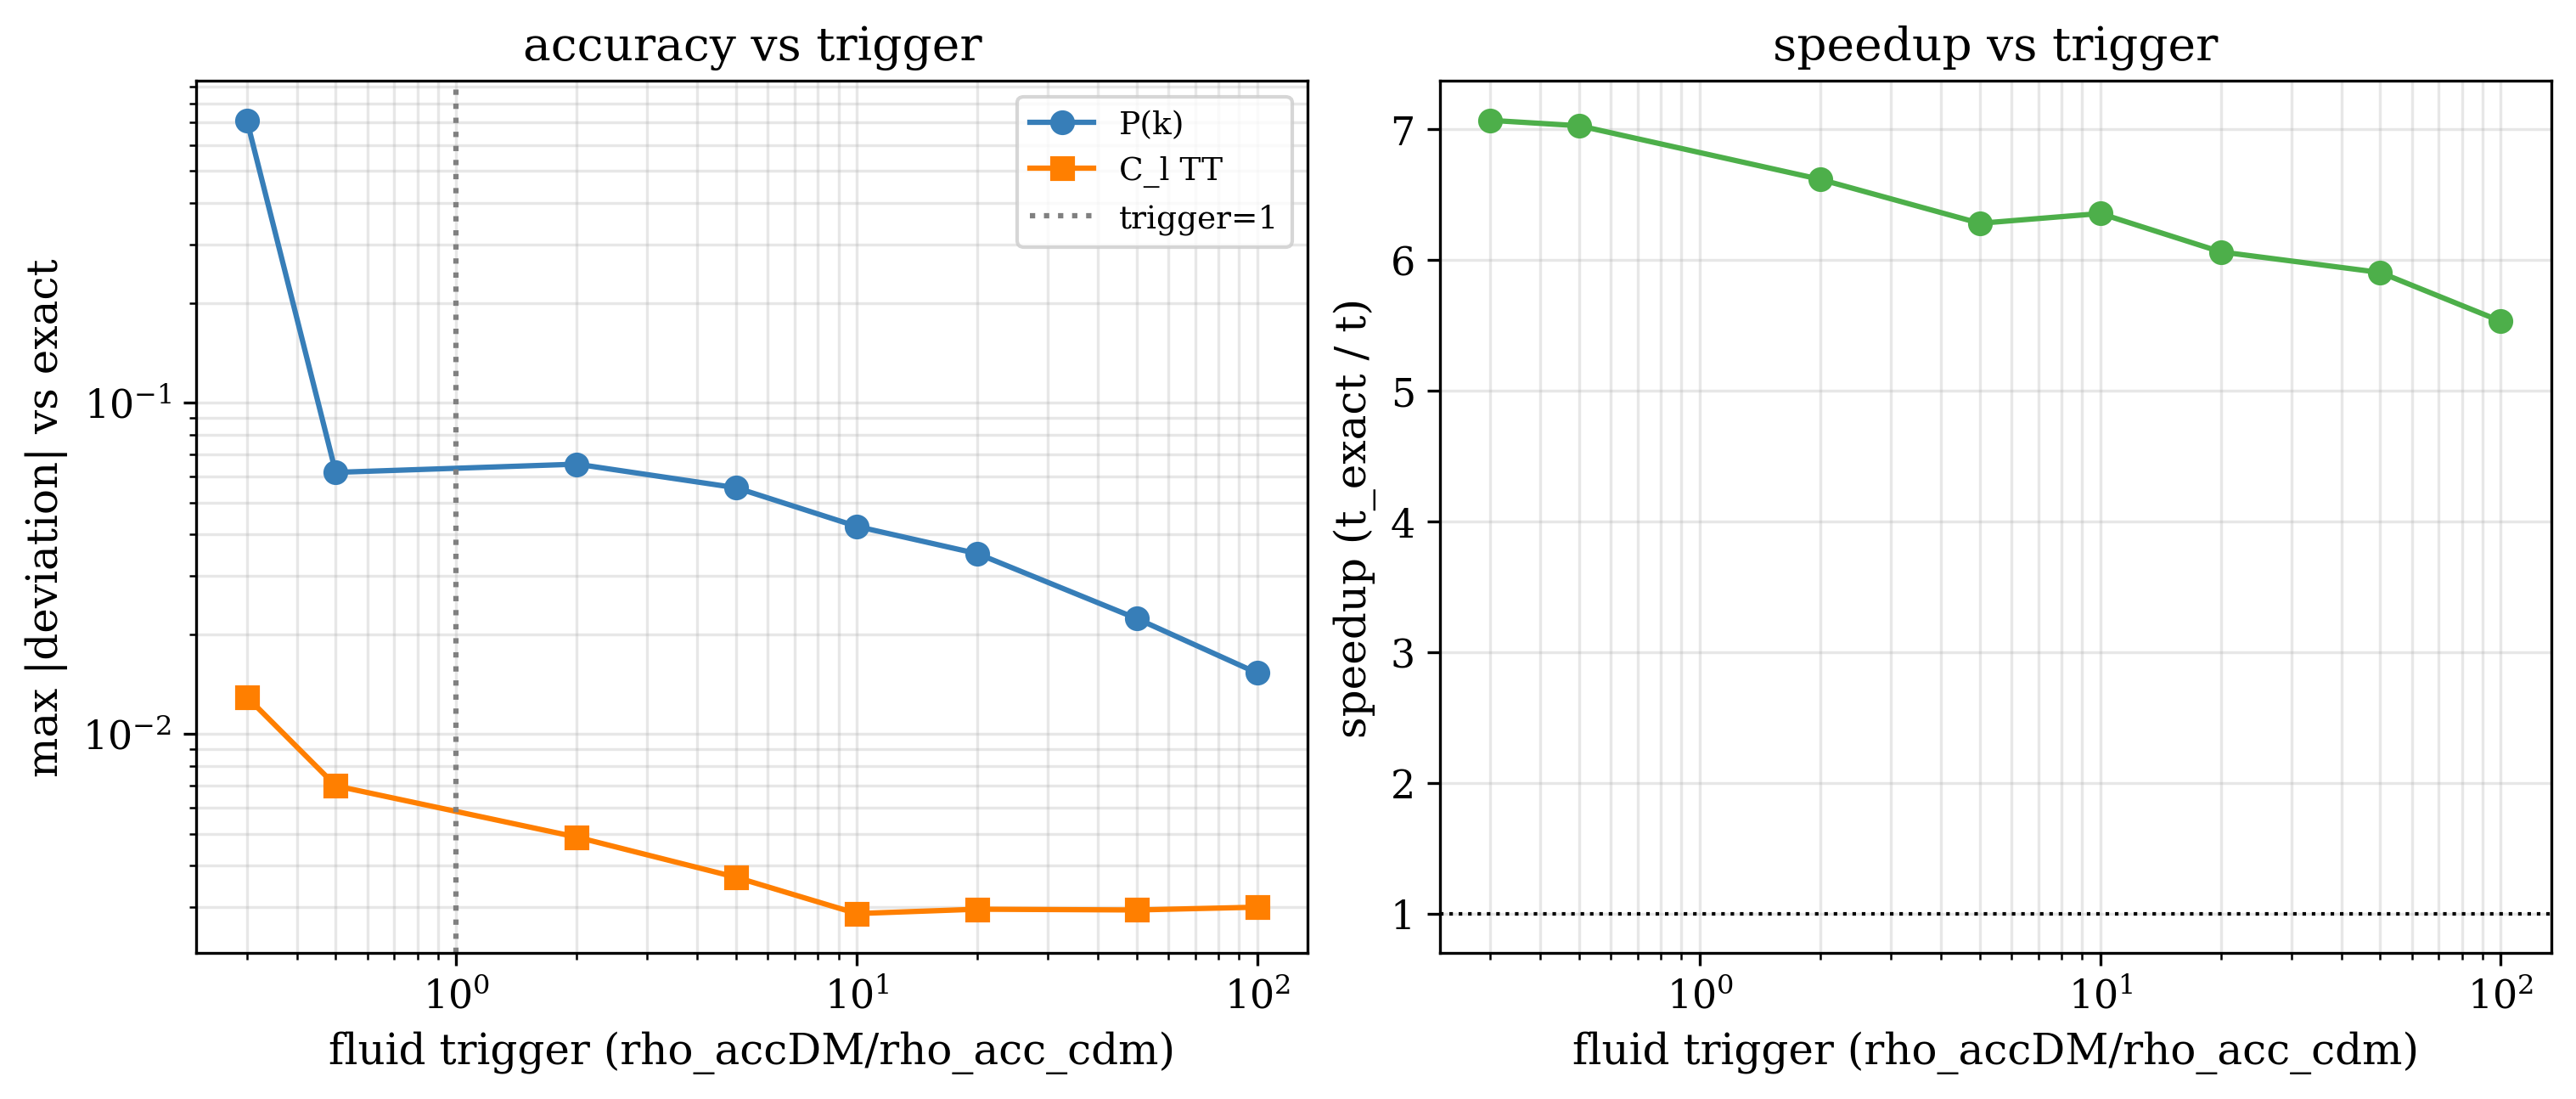

Reading it:
  - If the ratio (cell lt04) rises steeply through 0.3..2 near a_t, those triggers fire at nearly the
    same a -> similar speedup, and the larger ones have a gentler source (ratio_rho<1) = more stable.
  - Triggers flagged NO SWITCH never reached the ratio -> run stayed exact (1x, trivially stable).
  - Best fluid speedup here is still <= the small-trigger ~1.8x; the q_size reduction (nb 10) is the headline.


In [7]:
ok = [r for r in rows if r.get('ok')]
fig, ax = plt.subplots(1, 2, figsize=(10, 4.2), constrained_layout=True)
tr = [r['tr'] for r in ok]
ax[0].loglog(tr, [r['dpk'] for r in ok], 'o-', color=qual[0], label='P(k)')
ax[0].loglog(tr, [r['dcl'] for r in ok], 's-', color=qual[1], label='C_l TT')
ax[0].axvline(1.0, color='0.5', ls=':', label='trigger=1')
ax[0].set_xlabel('fluid trigger (rho_accDM/rho_acc_cdm)'); ax[0].set_ylabel('max |deviation| vs exact')
ax[0].set_title('accuracy vs trigger'); ax[0].legend(loc='best'); ax[0].grid(True, which='both', alpha=0.3)
ax[1].semilogx(tr, [r['sp'] for r in ok], 'o-', color=qual[2])
ax[1].axhline(1.0, color='k', ls=':', lw=1)
ax[1].set_xlabel('fluid trigger (rho_accDM/rho_acc_cdm)'); ax[1].set_ylabel('speedup (t_exact / t)')
ax[1].set_title('speedup vs trigger'); ax[1].grid(True, which='both', alpha=0.3)
plt.show()

print('Reading it:')
print('  - If the ratio (cell lt04) rises steeply through 0.3..2 near a_t, those triggers fire at nearly the')
print('    same a -> similar speedup, and the larger ones have a gentler source (ratio_rho<1) = more stable.')
print('  - Triggers flagged NO SWITCH never reached the ratio -> run stayed exact (1x, trivially stable).')
print('  - Best fluid speedup here is still <= the small-trigger ~1.8x; the q_size reduction (nb 10) is the headline.')

## Notes

- **This is a robustness option, not a speed win.** Larger trigger = later switch-on = less of the run is fluid, so the speedup is <= the ~1.8x already measured on the small-trigger side. The headline speedup remains the q_size reduction (notebook 10, 5-10x, exact hierarchy untouched).
- **Reachability is the catch.** If `rho_accDM/rho_acc_cdm` plateaus below a trigger (cell lt04), that trigger never fires and the fluid stays off (run is exact). Check the printed max ratio.
- **Synergy worth noting.** This runs at the reduced QBINS=250: fewer daughter momentum modes also means a less stiff fluid switch-on, so the reduced grid may WIDEN the stable trigger range vs notebook 6's q=1001. Compare the crash boundary here (if any) to notebook 6.
- The architectural fluid blow-up (memory: fluid-approx-unusable) is a warm/high-k phenomenon; large triggers switch on cold, so they should sit in the stable regime by construction.
- No rebuild needed: all knobs are runtime parameters against the built classy.